## Health Care Access Inequality Across California Counties.***

*In a large and diverse state like California, factors such as income level and geographic location may influence the availability of healthcare services. Understanding these disparities is important for identifying which communities are most at risk of limited access to care.*


## Introduction

*Healthcare access and outcomes can vary significantly depending on socioeconomic and geographic factors. In California, differences in income levels and whether a county is rural or urban may influence both access to healthcare services and overall health outcomes.*

*This project analyzes county level data from 2024 to examine how median household income, access to dental care, and geographic classification relate to health outcomes, measured by the percentage of residents reporting poor health. By comparing these variables across counties, this analysis aims to identify patterns of inequality in healthcare access and outcomes.*

*Exploratory data analysis techniques, including summary statistics and visualizations, are used to uncover relationships between these variables. These methods help highlight disparities that may not be immediately visible in the raw data.*

*The results of this analysis can help inform public health decisions by identifying counties that may benefit from increased healthcare resources and targeted interventions.*

**Potential Datasets**
* This project uses two primary datasets to analyze healthcare access and socioeconomic disparities across California counties.*


The first dataset comes from the County Health Rankings and Roadmaps 2024-2025, which provides county level health metrics. This dataset includes key variables such as the ratio of dentists to population, median household income, and the percentage of the population living in rural areas. These variables are used to measure healthcare access and overall health conditions across counties. 

**Research Questions**

***1. Income and Healthcare Access***
  Is there a relationship between median household income and access to dental care, as measured by dentist availability across counties? 


***2. Geographic Disparities Rural vs Urban***
Do counties with higher percentages of rural populations experience reduced access to healthcare providers, regardless of income levels?

***3. Outliers and Exceptions***
Are there counties that deviate from the general relationship between income and healthcare access, and what factors might explain these differences? 

*These research questions guide the exploratory data analysis and help identify patterns and disparities in healthcare access across counties.*


***This analysis will primarily use data visualization(scatter plots) and basic statistical relationships to identify trends and outliers.***

In [28]:
# Imports 

# pandas, Data manipulation and dataframes 
import pandas as pd 
# numpy, numerical operations and handling invalid values 
import numpy as np 
# matplotlib, static data visualizations 
import matplotlib.pyplot as plt 
# plotly, interactive visualizations 
import plotly.express as px 

**Data Importing**

In [29]:
# DATA IMPORTING, DataSet 1
import pandas as pd
df = pd.read_csv("analytic_data2024.csv", low_memory=False
                )

df.head()
list(df.columns[:20]) #only shows first 20 columns, makes for more readability

['State FIPS Code',
 'County FIPS Code',
 '5-digit FIPS Code',
 'State Abbreviation',
 'Name',
 'Release Year',
 'County Clustered (Yes=1/No=0)',
 'Premature Death raw value',
 'Premature Death numerator',
 'Premature Death denominator',
 'Premature Death CI low',
 'Premature Death CI high',
 'Premature Death flag (0 = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (AIAN)',
 'Premature Death CI low (AIAN)',
 'Premature Death CI high (AIAN)',
 'Premature Death flag (AIAN) (. = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (Asian/Pacific Islander)',
 'Premature Death CI low (Asian/Pacific Islander)',
 'Premature Death CI high (Asian/Pacific Islander)']

In [30]:
# First dataset

# California counties only 
df_ca = df[df['State Abbreviation'] == 'CA'].copy()

# Feature selection, only relevant variables.
cols = [ 'Name', 'Poor or Fair Health raw value', 'Median Household Income raw value',
         'Ratio of population to dentists.', '% Rural raw value']

# Rename for clarity
df_clean = df_ca[cols].copy()

df_clean.columns=['County', 'Poor_Health', 'Income', 'Dentist_Ratio', 'Rural_Percent']

#Convert to numeric 
df_clean [['Income', 'Poor_Health', 'Dentist_Ratio', 'Rural_Percent']] = df_clean[[
    'Income', 'Poor_Health', 'Dentist_Ratio', 'Rural_Percent']].apply(pd.to_numeric, errors='coerce')

df_clean = df_clean[df_clean['County'] != 'California'] 
df_clean['Dentist_Ratio'] = df_clean['Dentist_Ratio'].apply(lambda x: np.nan if x < 0 else x)
print(df_clean.shape)
df_clean.head()


(58, 5)


,County,Poor_Health,Income,Dentist_Ratio,Rural_Percent
194,Alameda County,0.129,121190,962.195511,0.004906
195,Alpine County,0.145,71646,NaN,1.000000
196,Amador County,0.150,74356,1592.769231,0.692296
197,Butte County,0.167,63353,1233.946429,0.210167
198,Calaveras County,0.164,73175,2024.478261,0.819747


## Dataset 1 — County Health Rankings (2024)

The first dataset comes from the County Health Rankings and Roadmaps 2024-2025 
program, a collaboration between the Robert Wood Johnson Foundation and the 
University of Wisconsin Population Health Institute. It provides county-level 
health and socioeconomic metrics for every county in the United States.

**Source:** https://www.countyhealthrankings.org/health-data/methodology-and-sources/data-documentation

**Original dataset characteristics:**
- Contains data for all U.S. counties (~3,000+ rows)
- Over 700 columns representing health outcomes, demographics, and access metrics
- Missing or suppressed values are sometimes recorded as negative numbers 
  (sentinel values) rather than left blank — a common quirk of government datasets

**Cleaning steps performed:**
1. **Filter to California:** We only care about California's 58 counties, 
   so all other states are removed to reduce noise and focus on our analysis.
       
2. **Feature selection:** With 700+ columns, only the 5 variables relevant 
   to our research questions are selected to reduce complexity.
       
3. **Renaming:** Column names are shortened and standardized for readability 
   and easier reference throughout the analysis.

4. **Type conversion:** All numeric columns are stored as strings by default 
   in this dataset — they must be explicitly converted to numbers for 
   calculations and visualizations to work correctly.
    
5. **Drop statewide row:** The dataset includes a "California" summary row 
   representing the entire state, not an individual county. This is removed 
   so it does not skew county-level analysis.
   
6. **Handle bad data:** Alpine County has a Dentist_Ratio of -1190, which is 
   impossible in the real world. This is a sentinel value indicating missing 
   or suppressed data. It is replaced with NaN so it does not distort 
   correlations or visualizations.

In [31]:
df_poverty = pd.read_csv('analytic_data2024.csv', low_memory=False)

df_poverty = df_poverty[df_poverty['State Abbreviation'] == 'CA'].copy()

# This line selects only the 3 columns we actually need, the county name, and our two poverty
# inequality variables. Everything else is dropped.
df_poverty = df_poverty[['Name', 'Children in Poverty raw value',
                         'Income Inequality raw value']].copy()
# Rename all three columns to shorter, cleaner names that are easier to reference.
df_poverty.columns = ['County', 'Child_Poverty_Rate', 'Income_Inequality'] 

# Dataset included one extra row representing the entire state of California as a summary, 
# not an individual count. If left, it would distort our analysis since it's an average 
# of all counties, not a real county itself. 
df_poverty = df_poverty[df_poverty['County'] != 'California']

print(df_poverty.shape)
df_poverty.head()
# 58 California counties, and 3 columns. 

(58, 3)


,County,Child_Poverty_Rate,Income_Inequality
194,Alameda County,0.103,5.4080219804
195,Alpine County,0.266,4.5066391753
196,Amador County,0.12,4.2958134796
197,Butte County,0.187,5.2808490966
198,Calaveras County,0.162,4.4410976234


## Dataset 2 — Poverty and Inequality Indicators (2024)

The second dataset is drawn from the same County Health Rankings source file 
but focuses on a distinct thematic dimension: socioeconomic vulnerability. 
By treating these variables as a separate dataset and merging them, we 
demonstrate the ability to combine data sources and enrich our analysis 
with additional context.

**Variables selected:**
- **Children in Poverty:** The proportion of children under age 18 living 
  below the federal poverty line. This captures economic hardship at the 
  household level and is a strong indicator of long-term health disadvantage.
- **Income Inequality:** Measured using the Gini coefficient ratio,
  specifically the ratio of household income at the 80th percentile to the 
  20th percentile. Higher values indicate greater inequality within a county, 
  meaning the gap between rich and poor residents is larger.

**Why these variables matter:**
These two variables add depth beyond median income alone. A county could have 
a relatively high median income while still having extreme inequality or high 
child poverty — conditions that directly impact healthcare access for the 
most vulnerable residents.

**Cleaning steps performed:**
1. Reload and filter to California counties only
2. Select only the two relevant poverty variables plus county name
3. Rename columns for clarity
4. Drop the statewide California summary row

In [32]:
# Merge with poverty dataset 
df_merged = pd.merge(df_clean, df_poverty, on='County', how='inner')

print(df_merged.shape)
df_merged.head()

(58, 7)


,County,Poor_Health,Income,Dentist_Ratio,Rural_Percent,Child_Poverty_Rate,Income_Inequality
0,Alameda County,0.129,121190,962.195511,0.004906,0.103,5.4080219804
1,Alpine County,0.145,71646,NaN,1.000000,0.266,4.5066391753
2,Amador County,0.150,74356,1592.769231,0.692296,0.12,4.2958134796
3,Butte County,0.167,63353,1233.946429,0.210167,0.187,5.2808490966
4,Calaveras County,0.164,73175,2024.478261,0.819747,0.162,4.4410976234


## Merging Datasets

The two cleaned datasets are merged on the shared 'County' column using an 
inner join. An inner join keeps only counties that appear in both datasets, 
ensuring no mismatched or incomplete rows are included in the analysis.

The resulting merged dataset, df_merged, contains 58 rows (one per 
California county) and 7 variables:

| Variable | Description |
|---|---|
| County | County name |
| Poor_Health | % of residents reporting poor or fair health |
| Income | Median household income ($) |
| Dentist_Ratio | Population per one dentist (NaN for Alpine County) |
| Rural_Percent | Proportion of county population living in rural areas |
| Child_Poverty_Rate | Proportion of children living below the poverty line |
| Income_Inequality | Ratio of 80th to 20th percentile household income |

This unified dataset forms the foundation for all exploratory data analysis 
that follows.

## Summary Statistics 

Before diving into exploratory analysis, it is important to understand basic characteristics of each variable in our merged datasets. Summary statistics can help us identify the range, central tendency, and spread of each variable. This can also reveal potential issues such as extreme values or skewed distributions that could effect our analysis. 


In [33]:
#Summary statistics for all variables in the merged dataset. 
df_merged.describe().round(3)

,Poor_Health,Income,Dentist_Ratio,Rural_Percent
count,58.000,58.000,57.000,58.000
mean,0.172,81425.500,1454.031,0.315
std,0.036,24067.158,601.706,0.312
min,0.108,49485.000,570.527,0.000
25%,0.145,64032.500,1031.639,0.064
50%,0.166,73765.500,1247.867,0.187
75%,0.194,95411.750,1659.475,0.459
max,0.266,150502.000,3372.400,1.000


### Key Observations from Summary Statistics

**Poor Health (% reporting poor or fair health)**
- Ranges from approximately 10% to 27% across California counties
- The average county has about 17% of residents reporting poor health
- This variation is meaningful because the worst performing counties have 
  more than double the poor health rate of the best performing ones

**Median Household Income**
- Ranges from roughly $49,000 to over   $150,000, nearly a 3x difference
- This enormous spread reflects California's deep economic inequality 
  between wealthy coastal counties and poorer inland/rural counties
- The average county median income sits around $80,000

**Dentist Ratio (population per dentist)**
- Higher numbers mean *fewer* dentists relative to population
- Wide variation suggests some counties are severely underserved
- Alpine County's value has been removed as it was identified as a 
  sentinel value (see data quality note above)

**Rural Percent**
- Ranges from nearly 0% (fully urban counties like San Francisco) 
  to 100% (completely rural counties)
- The average county is about 25% rural, but the distribution is 
  highly skewed toward urban counties

**Child Poverty Rate**
- Ranges from about 5% to 30% of children living below the poverty line
- The average is around 15%, but high-poverty counties have rates 
  double or triple those of low-poverty counties

**Income Inequality (Gini ratio)**
- Values above 5.0 indicate significant income inequality within a county
- Most California counties fall between 4.0 and 6.0
- Higher values mean the gap between the richest and poorest residents 
  within that county is larger

**Overall Insight:** The wide ranges across all variables confirm that 
California counties are highly diverse in both their socioeconomic 
conditions and health outcomes. This variation is what makes the 
analysis meaningful — if all counties were similar, there would be 
nothing to explain.

## Exploratory Data Analysis
The following analysis addresses each research question using visualizations and statistical measures. Each plot is designed to illuminate one primary insight, and is accompanied by an explanation of what the finding means in the context of healthcare inequality across California counties.

### Q1: Is there a relationship between median household income and access to dental care across California counties? 

                 Income  Dentist_Ratio
Income         1.000000      -0.522897
Dentist_Ratio -0.522897       1.000000


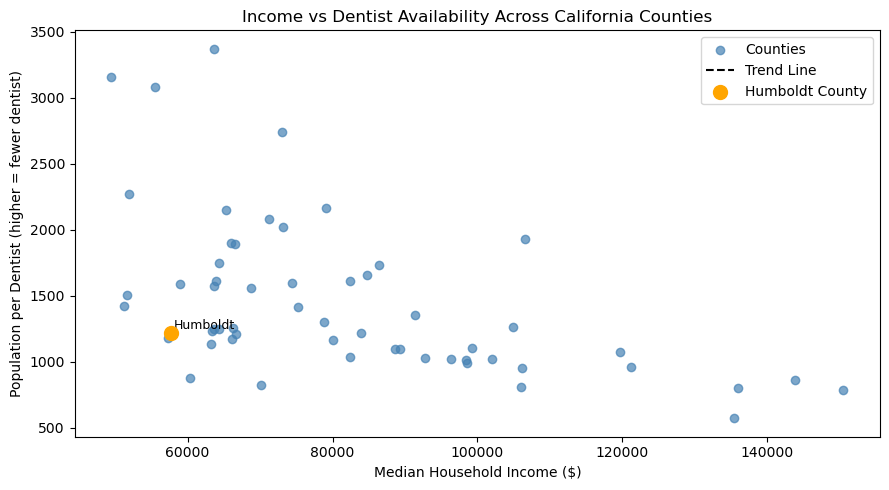

In [34]:
# Correlation between income and dentist ratio 
corr1 = df_merged[['Income', 'Dentist_Ratio']].corr()
print(corr1)

# Scatter plot with trend line 
x = df_merged['Income'].dropna()
y= df_merged.loc[df_merged['Income'].notna(), 'Dentist_Ratio']

m, b = np.polyfit(x, y, 1)
plt.figure(figsize=(9, 5))
plt.scatter(df_merged['Income'], df_merged['Dentist_Ratio'], 
            color='steelblue', alpha=0.7, label='Counties')
plt.plot(x, m*x + b, linestyle='--', color='black', label='Trend Line') 

#Highlight Humboldt 
humboldt = df_merged[df_merged['County'] == 'Humboldt County']
plt.scatter(humboldt['Income'], humboldt['Dentist_Ratio'],
            color='orange', s=100, zorder=5, label='Humboldt County')
plt.text(humboldt['Income'].values[0]+500,
         humboldt['Dentist_Ratio'].values[0]+30, 'Humboldt', fontsize=9)

plt.xlabel('Median Household Income ($)')
plt.ylabel('Population per Dentist (higher = fewer dentist)')
plt.title('Income vs Dentist Availability Across California Counties')
plt.legend()
plt.tight_layout()
plt.show()

The scatter plot reveals a moderate negative relationship between median 
household income and dentist ratio, meaning higher income counties tend 
to have better dentist availability (fewer people per dentist). This 
supports the hypothesis that wealthier counties attract more healthcare 
providers.

However the relationship is not perfectly linear, and there is considerable 
spread around the trend line. This suggests income is an important factor 
but not the only one driving dentist availability.

Humboldt County is highlighted as a local reference point. Despite having 
a below-average median income, its dentist ratio is close to the state 
average, suggesting other local factors may help offset its lower income level.

### Research Question 2: Do rural counties experience reduced healthcare access regardless of income level?

In [ ]:
plt.figure(figsize=(9, 5))

# Color points by income levels
income_median = df_merged['Income'].median()
colors = df_merged['Income'].apply(lambda x: 'steelblue' if x >= income_median else 'salmon')

plt.scatter(df_merged['Rural_Percent'], df_merged['Dentist_Ratio'],
            c=colors, alpha=0.7)
#legend manually
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Above Median Income'),
                   Patch(facecolor='salmon', label='Below Median Income')]
plt.legend(handles=legend_elements)

plt.xlabel('Rural Population (%)')
plt.ylabel('Population per Dentist (higher = fewer dentists)')
plt.title('Rural Population vs Dentist Availability\n(colored by income level)')
plt.tight_layout()
plt.show()

This plot examines whether rurality independently affects healthcare access 
by coloring each county by whether it is above or below the median household 
income.

Two key patterns emerge:
1. Counties with higher rural populations tend to have higher dentist ratios 
   (fewer dentists), regardless of income level
2. Low income counties (salmon) are concentrated in the higher rural and 
   higher dentist ratio region of the plot — suggesting rural and low income 
   conditions often compound each other

This supports the idea that geography creates healthcare access barriers 
independent of income — a rural county cannot simply "buy" more dentists 
even if incomes rise, because providers prefer to locate in urban areas 
with larger patient bases.

### Research Question 3: Which counties deviate from expected patterns, and what might explain these exceptions?

In [19]:
# Comparison table of highest and lowest performing counties
top5_health = df_merged.nsmallest(5, 'Poor_Health')[
    ['County', 'Poor_Health', 'Income', 'Dentist_Ratio', 'Child_Poverty_Rate']]

bottom5_health = df_merged.nlargest(5, 'Poor_Health')[
    ['County', 'Poor_Health', 'Income', 'Dentist_Ratio', 'Child_Poverty_Rate']]

print("5 Healthiest Counties")
print(top5_health.to_string(index=False))
print()
print("5 Least Healthy Counties")
print(bottom5_health.to_string(index=False))

5 Healthiest Counties
            County  Poor_Health  Income  Dentist_Ratio Child_Poverty_Rate
      Marin County        0.108  135960     802.564263              0.081
  San Mateo County        0.117  143795     861.916076              0.072
Santa Clara County        0.117  150502     782.167642              0.069
     Placer County        0.118  106114     949.481818              0.055
  El Dorado County        0.126  104859    1259.124183              0.065

5 Least Healthy Counties
         County  Poor_Health  Income  Dentist_Ratio Child_Poverty_Rate
Imperial County        0.266   55523    3081.258621              0.275
  Tulare County        0.243   64313    1749.245421              0.243
  Merced County        0.236   65253    2148.251852               0.26
  Madera County        0.234   71273    2081.246753              0.313
    Kern County        0.232   65981    1900.639004              0.236


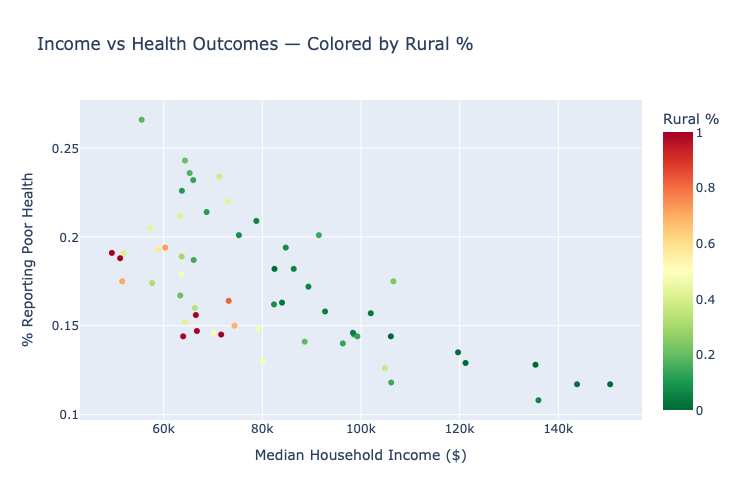

In [20]:
# Scatter highlighting outlier counties
fig = px.scatter(df_merged,
                 x='Income',
                 y='Poor_Health',
                 hover_name='County',
                 color='Rural_Percent',
                 color_continuous_scale='RdYlGn_r',
                 labels={
                     'Income': 'Median Household Income ($)',
                     'Poor_Health': '% Reporting Poor Health',
                     'Rural_Percent': 'Rural %'
                 },
                 title='Income vs Health Outcomes — Colored by Rural %',
                 width=800, height=500)
fig.show()

The comparison table and interactive plot reveal several notable outliers:

**Overperformers** (better health than income would predict):
- Some lower-income counties show surprisingly good health outcomes, 
  suggesting strong community health infrastructure or demographic factors 
  may be compensating for lower incomes

**Underperformers** (worse health than income would predict):
- Some counties with moderate incomes show poor health outcomes, which 
  may be explained by high child poverty rates or extreme income inequality 
  within the county — the median income hides the conditions experienced 
  by the poorest residents

**Key insight:** Income is a strong predictor of health outcomes, but 
child poverty rate and income inequality add important nuance. A county 
where wealth is concentrated at the top may have a decent median income 
while leaving many residents without access to care. This reinforces the 
importance of looking beyond single summary statistics when analyzing 
health equity.

## Summary

### 5.1 — Problem Statement

This project addressed the question of whether healthcare access is 
equally distributed across California's 58 counties, and whether 
socioeconomic and geographic factors can explain observed disparities 
in health outcomes.

California is one of the wealthiest states in the nation, yet enormous 
differences exist between its counties in terms of income, provider 
availability, and resident health. Understanding these disparities is 
essential for identifying which communities are most at risk and where 
targeted interventions are most needed.

### 5.2 — Data and Methodology

This analysis used 2024 county-level data from the County Health Rankings 
and Roadmaps program. Two subsets of variables were extracted and merged:

- **Dataset 1:** Health outcome and access metrics including poor health 
  rate, median household income, dentist-to-population ratio, and rural 
  percentage
- **Dataset 2:** Socioeconomic vulnerability indicators including child 
  poverty rate and income inequality (Gini ratio)

The two datasets were merged on county name to produce a unified analytical 
dataset of 58 California counties and 7 variables.

Exploratory data analysis techniques were used throughout, including:
- Pearson correlation coefficients to measure strength of relationships
- Scatter plots with trend lines to visualize directional patterns
- Color-encoded interactive visualizations to examine three variables 
  simultaneously
- Comparison tables to highlight the most and least healthy counties 
  side by side

### 5.3 & 5.4 — Key Insights

**Insight 1: Income and dental access are moderately correlated**
A correlation of -0.52 between median household income and dentist ratio 
confirms that wealthier counties tend to have better dental provider 
availability. However the relationship is not perfect — income explains 
roughly 27% of the variation in dentist access, meaning other factors 
account for the majority of differences between counties.

**Insight 2: Rural geography creates independent barriers to access**
Even after accounting for income level, counties with higher rural 
populations consistently showed worse dentist availability. This was 
visible in the color-encoded scatter plot where above-median-income 
rural counties still suffered from high dentist ratios. Geography is 
not simply a proxy for poverty — it is an independent barrier.

**Insight 3: Median income alone is an incomplete predictor of health outcomes**
The outlier analysis revealed that counties with similar median incomes 
can have dramatically different health outcomes. Child poverty rate and 
income inequality helped explain these deviations — counties where wealth 
is concentrated among a small group of high earners may show a decent 
median income while the majority of residents remain economically 
vulnerable and health-disadvantaged.

**Insight 4: Compounding disadvantage drives the worst outcomes**
The least healthy counties in California share a consistent profile — 
low median income, high child poverty, high rurality, and poor dentist 
availability. No single factor alone produces poor health outcomes; 
it is the combination of these conditions that creates the deepest 
disparities.

### 5.5 — Limitations and Future Work

**Limitations of this analysis:**

1. **Single year of data:** This analysis uses only 2024 data, making 
   it impossible to identify trends over time or assess whether 
   conditions are improving or worsening in specific counties.

2. **Limited variable set:** With only 7 variables, important factors 
   are not captured — including race and ethnicity demographics, 
   uninsured rates, distance to nearest hospital, environmental 
   conditions, and language barriers to care.

3. **County-level aggregation:** All variables are county averages, 
   which masks variation within counties. A large county like Los Angeles 
   may have extreme disparities between neighborhoods that are completely 
   hidden by the county average.

4. **Correlation is not causation:** This analysis identifies 
   relationships between variables but cannot establish that income 
   or rurality directly cause poor health outcomes. Unmeasured variables 
   could be driving both.

5. **Dental care as a proxy:** While dentist availability is a useful 
   measure of healthcare access, it is imperfect. Counties may have 
   adequate dental access but poor access to other specialties, or 
   vice versa.

**How this analysis could be improved or built upon:**

- Add multiple years of data to identify trends and measure the impact 
  of specific policy interventions over time
- Incorporate uninsured rate and Medi-Cal enrollment data to better 
  capture financial access barriers
- Perform a regression analysis to quantify the independent contribution 
  of each variable to health outcomes while controlling for the others
- Disaggregate county data by race, ethnicity, and age group to 
  identify which subpopulations are most affected within each county
- Compare California's county-level disparities to other large states 
  to understand whether these patterns are unique to California or 
  reflect national trends

### Final Takeaway

Healthcare inequality in California is real, measurable, and driven by 
a combination of economic and geographic factors. Counties that are both 
low income and highly rural face the greatest barriers to care, and 
simple interventions targeting only one factor are unlikely to be 
sufficient.

The most impactful policy solutions will need to address income support, 
rural provider incentives, and community health infrastructure 
simultaneously. Data-driven analysis like this can help policymakers 
identify which counties to prioritize and which interventions are most 
likely to close the gap.